In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt
from mmdet.core.evaluation.metric_custom import ClassifierPerformanceBinary
user_home = os.environ['HOME']
print(user_home)




/home/dejuns


In [19]:
model_id = 'convnext_s32c32em4_stoic2kcv05_224x224x192_covid_scratch'
save_dir = Path(f'{user_home}/git/stoic2021/work_dirs/{model_id}')
info_fp = save_dir/f'result_by_pid_test.csv'
info_tb = pd.read_csv(info_fp)
info_tb.set_index('pid', inplace=True)
print(info_tb.describe())
print(info_tb.head())

       cls0_gt_catg  cls0_pred_prob
count    400.000000      400.000000
mean       0.585000        0.615887
std        0.493339        0.114564
min        0.000000        0.248534
25%        0.000000        0.546042
50%        1.000000        0.648633
75%        1.000000        0.709699
max        1.000000        0.775095
       cls0_gt_catg cls0_gt_name  cls0_pred_catg cls0_pred_name  \
pid                                                               
10085             1        covid            True          covid   
10112             0           BG            True          covid   
10155             1        covid            True          covid   
10206             0           BG            True          covid   
10276             1        covid            True          covid   

       cls0_pred_prob  
pid                    
10085        0.627038  
10112        0.643665  
10155        0.724773  
10206        0.628293  
10276        0.732018  


In [2]:
# model_id = 'resnset_s32c16em2_stoic2kcv15_256x224x224_2cls'
model_id = 'resnset_s32c16em2_stoic2kcv15_256x224x224_2cls_agecode_ecloss'
work_dir = Path(f'{user_home}/git/stoic2021/work_dirs')
save_dir = work_dir/model_id/'visual_stoic2021_test_nii'
split_result_fps = [save_dir/a for a in os.listdir(save_dir) if 'aug' in a]
split_result_tbs = [pd.read_csv(fp) for fp in split_result_fps]

if len(split_result_tbs) > 1: 
    info_tb = pd.concat(split_result_tbs, axis = 0)
else:
    info_tb = split_result_tbs[0]
info_tb['pid'] = info_tb['pid'].apply(lambda x: int(x))
info_tb.set_index('pid', inplace=True)
# print(info_tb.describe())
# print(info_tb.head())



In [3]:
hand_feat_fn = 'information_v4.csv'
hand_feat_tb = pd.read_csv(work_dir/hand_feat_fn)
hand_feat_tb['id'] = hand_feat_tb['id'].apply(lambda x: int(x))
hand_feat_tb.set_index('id', inplace = True)
# print(hand_feat_tb.describe())

info_tb['ratio_p'] = [hand_feat_tb.loc[int(i), 'ratio_p'] for i in info_tb.index]


# print(info_tb['ratio_p'].describe())

In [4]:
metric_results = []
for i in range(2):
    metric_cls0 = ClassifierPerformanceBinary(info_tb[f'cls{i}_gt_catg'], info_tb[f'cls{i}_pred_prob'], 
                                                cls_name=str(i), model_name='resnet34')
    for k, v in metric_cls0.items(): print(k, v)
    metric_results.append(metric_cls0)


resnet34 0 threshold 0.5 acc0.7425 recall0.8583 ppv0.7649 auc0.7897
0_acc 0.7425
0_recall 0.8582677165354331
0_precis 0.7649122807017544
0_auc 0.7897476000431454

resnet34 1 threshold 0.5 acc0.8400 recall0.1212 ppv0.5714 auc0.7161
1_acc 0.84
1_recall 0.12121212121212122
1_precis 0.5714285714285714
1_auc 0.7160678642714571


[scipy] corr 0.7291920674650637 p_value 1.473504258091653e-67


Text(0.5, 0.8, 'resnset_s32c16em2_stoic2kcv15_256x224x224_2cls_agecode_ecloss')

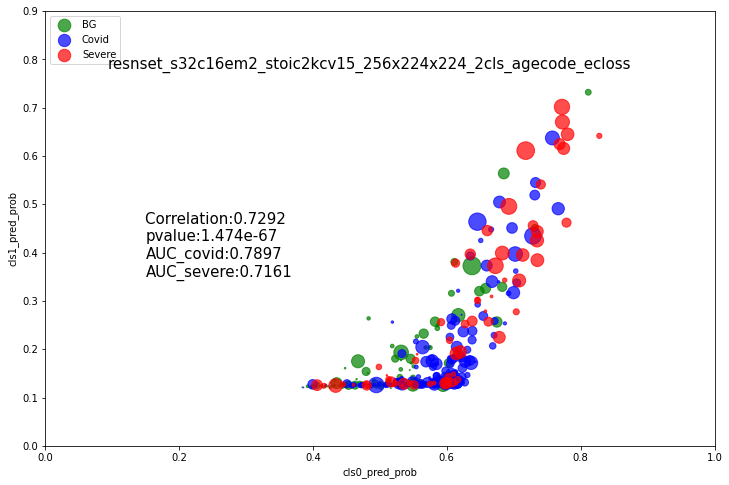

In [5]:
colors =  [] 
info_tb['ratio_p_50'] = info_tb['ratio_p'].apply(lambda x : x * 500)

bg_mask = info_tb['cls0_gt_catg'] == 0
covid_mask = (info_tb['cls0_gt_catg'] == 1) & (info_tb['cls1_gt_catg'] == 0)
severe_mask = info_tb['cls1_gt_catg'] == 1
group_infos = [ {'group': 'BG', 'color': 'green', 'mask': bg_mask}, 
                {'group': 'Covid', 'color': 'blue', 'mask': covid_mask}, 
                {'group': 'Severe', 'color': 'red', 'mask': severe_mask}, 
                 ]

fig, ax1 = plt.subplots()

for group_info in group_infos:
    
    this_group_tb = info_tb.loc[group_info['mask'], :]
    this_group_tb.plot.scatter(x = 'cls0_pred_prob', 
                              y = 'cls1_pred_prob', 
                               s = 'ratio_p_50', 
                              label = group_info['group'], ax = ax1, 
                              c=group_info['color'], alpha = 0.7, figsize = (12, 8))
ax1.set_xlim(0.0, 1.0)
ax1.set_ylim(0.0, 0.9)
from scipy.stats.stats import pearsonr
corr, p_value = pearsonr(info_tb['cls0_pred_prob'], info_tb['cls1_pred_prob'])
print(f'[scipy] corr {corr} p_value {p_value}')
covid_auc = round(metric_results[0]['0_auc'], 4)
severe_auc = round(metric_results[1]['1_auc'], 4)
corr_result_string = f'Correlation:{corr :.4} \npvalue:{p_value :.4}\nAUC_covid:{covid_auc}\nAUC_severe:{severe_auc}'
ax1.annotate(corr_result_string, 
            (0.15, 0.35), # these are the coordinates to position the label
             color='black', size = 15)
ax1.legend(loc = 'upper left')
fig.suptitle(f'{model_id}',  x=0.5, y=0.8, size = 15)

In [ ]:
# gt_by_pred = pd.crosstab(info_tb['cls0_gt_name'] , info_tb['cls0_pred_name'], margins = True )
# print(gt_by_pred)
# recall = 218/234
# ppv = 218/343
# acc = (41 + 218) / (400)
# print(recall, ppv, acc)
# severe_nocovid_mask = (info_tb[f'cls0_pred_catg'] == 0) & (info_tb[f'cls1_pred_catg'] == 1)
# print('severe but not covid', severe_nocovid_mask.sum())